# 🛒 SmartCart Customer Segmentation System

## Problem Statement
SmartCart is a growing e-commerce platform with **2240 customers** and **22 features**.
The goal is to segment customers into meaningful groups using **Unsupervised Machine Learning**
to enable personalised marketing and improve customer retention.

## Dataset Features
- **Customer Demographics** — Age, Income, Education, Marital Status
- **Purchase Amount** — Wines, Fruits, Meat, Fish, Sweets, Gold
- **Purchase Frequency** — Web, Store, Catalog, Deals purchases
- **Customer Feedback** — Recency, Complaints

## Algorithms Used
- K-Means Clustering
- Hierarchical Clustering  
- DBSCAN

**Author:** Adnan | 300 Days of AI-ML Challenge | Day 118-141


In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load Dataset
df = pd.read_csv('smartcart_customers.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head(5)
df.info()


Shape: (2240, 22)

First 5 rows:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDe

## 2. Exploratory Data Analysis (EDA)
### 2.1 Missing Value Analysis

In [3]:
# Missing Value Analysis

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_pct
})

print(missing_df[missing_df['Missing Values'] > 0])

        Missing Values  Percentage
Income              24    1.071429


### 2.2 Basic Statistics

In [4]:
print(df.describe())

                 ID   Year_Birth         Income      Kidhome     Teenhome  \
count   2240.000000  2240.000000    2216.000000  2240.000000  2240.000000   
mean    5592.159821  1968.805804   52247.251354     0.444196     0.506250   
std     3246.662198    11.984069   25173.076661     0.538398     0.544538   
min        0.000000  1893.000000    1730.000000     0.000000     0.000000   
25%     2828.250000  1959.000000   35303.000000     0.000000     0.000000   
50%     5458.500000  1970.000000   51381.500000     0.000000     0.000000   
75%     8427.750000  1977.000000   68522.000000     1.000000     1.000000   
max    11191.000000  1996.000000  666666.000000     2.000000     2.000000   

           Recency     MntWines    MntFruits  MntMeatProducts  \
count  2240.000000  2240.000000  2240.000000      2240.000000   
mean     49.109375   303.935714    26.302232       166.950000   
std      28.962453   336.597393    39.773434       225.715373   
min       0.000000     0.000000     0.000000  

### 2.3 Distribution Plots

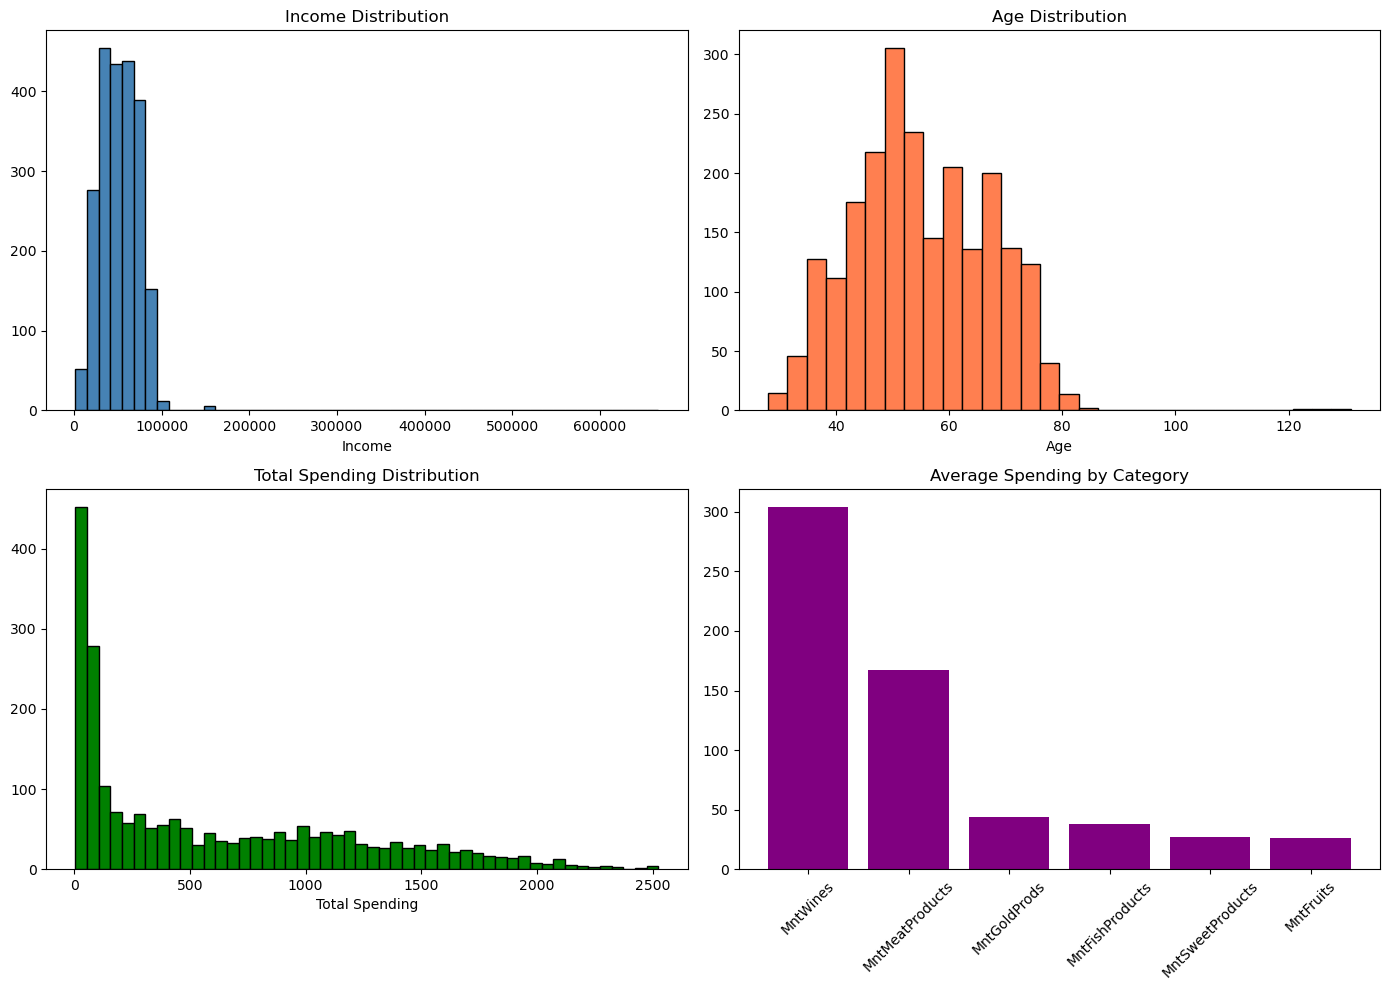

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Income Distribution
axes[0,0].hist(df['Income'].dropna(), bins=50, color='steelblue', edgecolor='black')
axes[0,0].set_title('Income Distribution')
axes[0,0].set_xlabel('Income')

# Age Distribution
df['Age'] = 2024 - df['Year_Birth']
axes[0,1].hist(df['Age'], bins=30, color='coral', edgecolor='black')
axes[0,1].set_title('Age Distribution')
axes[0,1].set_xlabel('Age')

# Total Spending
spend_cols = ['MntWines','MntFruits','MntMeatProducts',
              'MntFishProducts','MntSweetProducts','MntGoldProds']
df['Total_Spending'] = df[spend_cols].sum(axis=1)
axes[1,0].hist(df['Total_Spending'], bins=50, color='green', edgecolor='black')
axes[1,0].set_title('Total Spending Distribution')
axes[1,0].set_xlabel('Total Spending')

# Spending by Category
spend_means = df[spend_cols].mean().sort_values(ascending=False)
axes[1,1].bar(spend_means.index, spend_means.values, color='purple')
axes[1,1].set_title('Average Spending by Category')
axes[1,1].set_xticks(range(len(spend_means.index)))
axes[1,1].set_xticklabels(spend_means.index, rotation=45)

plt.tight_layout()
plt.savefig('outputs/plots/distributions.png')
plt.show()

### 2.4 Correlation Heatmap

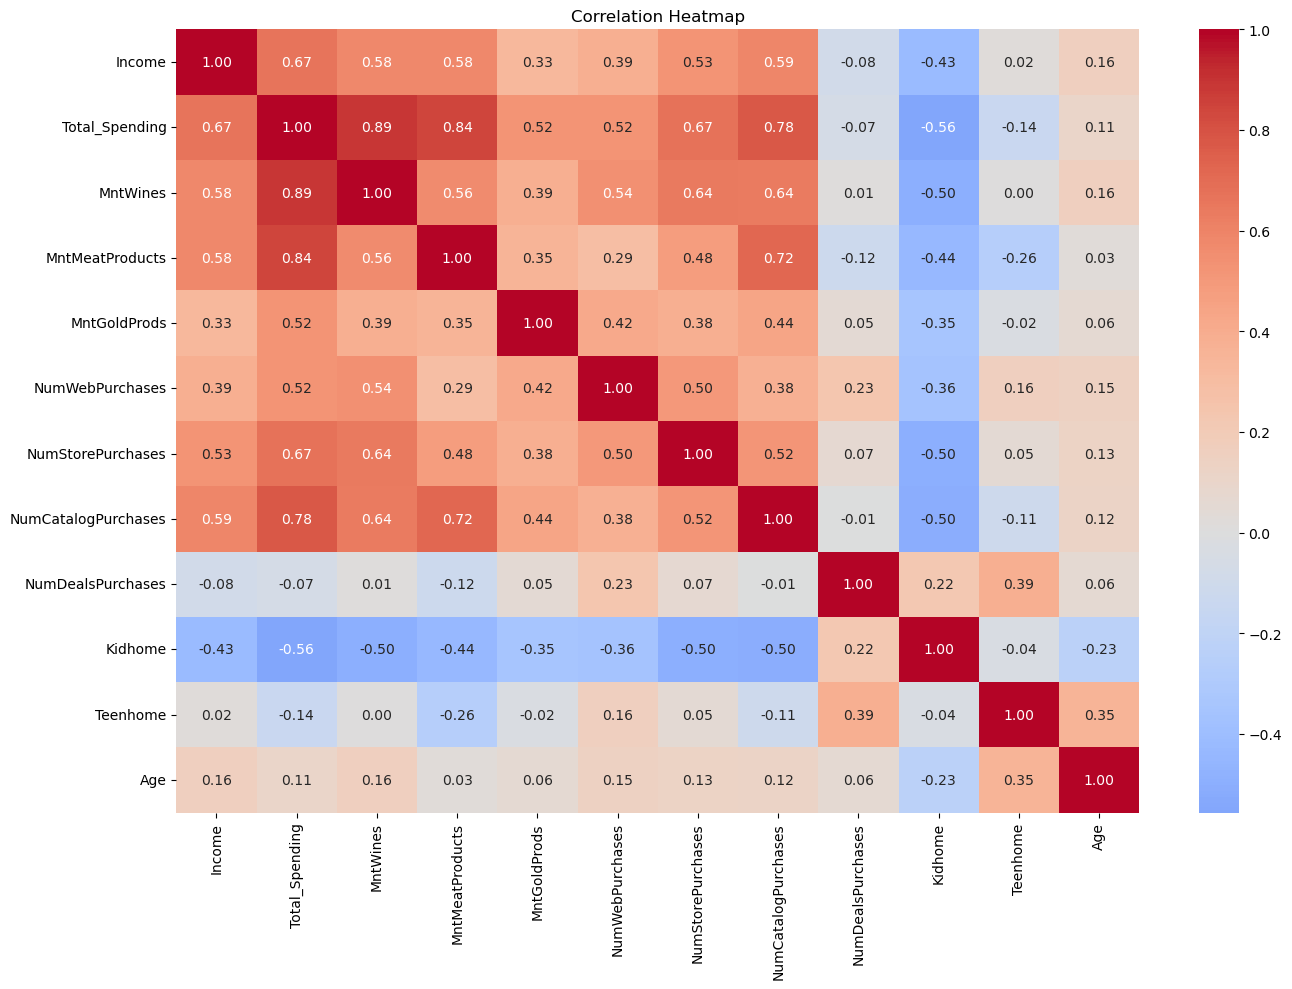

In [6]:
plt.figure(figsize=(14, 10))
spending_purchase_cols = ['Income', 'Total_Spending', 'MntWines', 
                          'MntMeatProducts', 'MntGoldProds',
                          'NumWebPurchases', 'NumStorePurchases',
                          'NumCatalogPurchases', 'NumDealsPurchases',
                          'Kidhome', 'Teenhome', 'Age']

sns.heatmap(df[spending_purchase_cols].corr(), 
            annot=True, 
            fmt='.2f',
            cmap='coolwarm',
            center=0)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('outputs/plots/correlation_heatmap.png')
plt.show()

## 3. Data Preprocessing
### 3.1 Remove Outliiers

In [7]:
print("Before removing outliers:", df.shape)

# Remove Income outlier (666666)
df = df[df['Income'] < 200000]

# Remove Age outliers (born before 1900)
df = df[df['Age'] < 100]

print("After removing outliers:", df.shape)
print("\nIncome max now:", df['Income'].max())
print("Age max now:", df['Age'].max())

Before removing outliers: (2240, 24)
After removing outliers: (2212, 24)

Income max now: 162397.0
Age max now: 84


### 3.2 Handle Missing Values

In [8]:
# Fill missing Income with median (median is better than mean for skewed data)
df['Income']=df['Income'].fillna(df['Income'].median())

print("Missing values after fix:")
print(df.isnull().sum().sum(), "missing values remaining")

Missing values after fix:
0 missing values remaining


### 3.3 Feature Engineering

In [9]:
# Total children at home
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

# Total purchases across all channels
df['Total_Purchases'] = (df['NumWebPurchases'] + df['NumStorePurchases'] + 
                         df['NumCatalogPurchases'] + df['NumDealsPurchases'])

print("New features added:")
print(df[['Age', 'Total_Spending', 'Total_Children', 'Total_Purchases']].head())
print("\nDataset shape now:", df.shape)

New features added:
   Age  Total_Spending  Total_Children  Total_Purchases
0   67            1617               0               25
1   70              27               2                6
2   59             776               0               21
3   40              53               1                8
4   43             422               1               19

Dataset shape now: (2212, 26)


### 3.4 Drop Unnecessary Columns

In [10]:
# These columns won't help clustering
cols_to_drop = ['ID', 'Year_Birth', 'Dt_Customer', 'Complain', 'Response']

df_clean = df.drop(columns=cols_to_drop)

print("Columns remaining:", df_clean.shape[1])
print(df_clean.columns.tolist())

Columns remaining: 21
['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Age', 'Total_Spending', 'Total_Children', 'Total_Purchases']


### 3.5 Encode Categorical Variables

In [11]:
# Checking unique values first
print("Education values:", df_clean['Education'].unique())
print("Marital_Status values:", df_clean['Marital_Status'].unique())

Education values: ['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']
Marital_Status values: ['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']


In [12]:
# Education — ordinal encoding (Basic < Graduation < Master < PhD)
education_order = {
    'Basic': 0,
    '2n Cycle': 1,
    'Graduation': 2,
    'Master': 3,
    'PhD': 4
}
df_clean['Education'] = df_clean['Education'].map(education_order)

# Marital Status — simplify first, then encode
marital_map = {
    'Married': 'Married',
    'Together': 'Married',    # living together = similar to married
    'Single': 'Single',
    'Divorced': 'Single',     # living alone
    'Widow': 'Single',        # living alone
    'Alone': 'Single',
    'Absurd': 'Single',       # unknown = single
    'YOLO': 'Single'          # ha ha ha  laughing emoji= single
}
df_clean['Marital_Status'] = df_clean['Marital_Status'].map(marital_map)
df_clean['Marital_Status'] = df_clean['Marital_Status'].map({'Married': 1, 'Single': 0})

print("Encoding done!")
print(df_clean[['Education', 'Marital_Status']].head(10))
print("\nAny nulls?", df_clean.isnull().sum().sum())

Encoding done!
   Education  Marital_Status
0          2               0
1          2               0
2          2               1
3          2               1
4          4               1
5          3               1
6          2               0
7          4               1
8          4               1
9          4               1

Any nulls? 0


### 3.6 Feature Scaling

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clean)

# Convert back to DataFrame for readability
df_scaled = pd.DataFrame(df_scaled, columns=df_clean.columns)

print("Scaling done!")
print("\nBefore scaling - Income mean:", round(df_clean['Income'].mean(), 2))
print("After scaling - Income mean:", round(df_scaled['Income'].mean(), 2))
print("\nBefore scaling - Income std:", round(df_clean['Income'].std(), 2))
print("After scaling - Income std:", round(df_scaled['Income'].std(), 2))
print("\nScaled data shape:", df_scaled.shape)

Scaling done!

Before scaling - Income mean: 51958.81
After scaling - Income mean: -0.0

Before scaling - Income std: 21527.28
After scaling - Income std: 1.0

Scaled data shape: (2212, 21)


### 3.7 Preprocessing Summary

In [14]:
print("=" * 40)
print("PREPROCESSING SUMMARY")
print("=" * 40)
print(f"Original shape:        (2240, 22)")
print(f"After cleaning shape:  {df_scaled.shape}")
print(f"Outliers removed:      28")
print(f"Missing values fixed:  24 (Income median fill)")
print(f"New features created:  Age, Total_Spending, Total_Children, Total_Purchases")
print(f"Columns dropped:       ID, Year_Birth, Dt_Customer, Complain, Response")
print(f"Encoding:              Education (ordinal), Marital_Status (binary)")
print(f"Scaling:               StandardScaler (mean=0, std=1)")
print("=" * 40)
print("Data is ready for clustering!")


PREPROCESSING SUMMARY
Original shape:        (2240, 22)
After cleaning shape:  (2212, 21)
Outliers removed:      28
Missing values fixed:  24 (Income median fill)
New features created:  Age, Total_Spending, Total_Children, Total_Purchases
Columns dropped:       ID, Year_Birth, Dt_Customer, Complain, Response
Encoding:              Education (ordinal), Marital_Status (binary)
Scaling:               StandardScaler (mean=0, std=1)
Data is ready for clustering!


## 4. K-Means Clustering
### 4.1 Finding Optimal K — Elbow Method

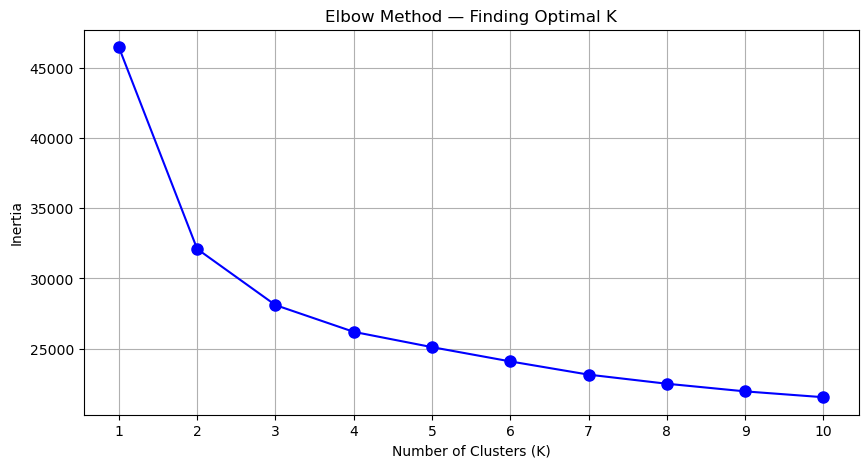

Inertia values:
K=1: 46452.00
K=2: 32095.38
K=3: 28102.91
K=4: 26197.44
K=5: 25108.33
K=6: 24093.25
K=7: 23152.57
K=8: 22504.75
K=9: 21960.94
K=10: 21545.09


In [15]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Finding Optimal K')
plt.xticks(K_range)
plt.grid(True)
plt.savefig('outputs/plots/elbow_method.png')
plt.show()

print("Inertia values:")
for k, inertia in zip(K_range, inertias):
    print(f"K={k}: {inertia:.2f}")

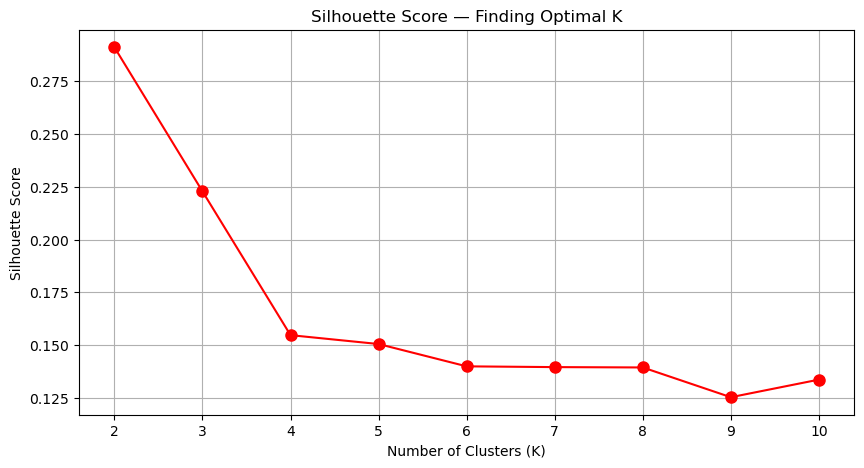

Silhouette Scores:
K=2: 0.2912
K=3: 0.2229
K=4: 0.1547
K=5: 0.1505
K=6: 0.1399
K=7: 0.1396
K=8: 0.1394
K=9: 0.1253
K=10: 0.1336


In [16]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(K_range, silhouette_scores, 'ro-', markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score — Finding Optimal K')
plt.xticks(K_range)
plt.grid(True)
plt.savefig('outputs/plots/silhouette_scores.png')
plt.show()

print("Silhouette Scores:")
for k, score in zip(K_range, silhouette_scores):
    print(f"K={k}: {score:.4f}")

### 4.3 Final K-Means Model (K=3)

In [17]:
# Final K-Means with K=3
kmeans_final = KMeans(n_clusters=3, n_init=10, random_state=42)
df_clean['Cluster'] = kmeans_final.fit_predict(df_scaled)

print("Cluster Distribution:")
print(df_clean['Cluster'].value_counts().sort_index())
print("\nTotal customers:", len(df_clean))

Cluster Distribution:
Cluster
0     600
1    1040
2     572
Name: count, dtype: int64

Total customers: 2212


### 4.4 Cluster Analysis — Who Are These Customers?

In [18]:
# Analyzing each cluster
cluster_analysis = df_clean.groupby('Cluster')[['Income', 'Age', 'Total_Spending', 
                                                  'Total_Purchases', 'Total_Children',
                                                  'MntWines', 'MntMeatProducts',
                                                  'NumWebPurchases', 'NumStorePurchases',
                                                  'NumCatalogPurchases']].mean().round(2)

print("Cluster Profiles:")
print(cluster_analysis.to_string())

Cluster Profiles:
           Income    Age  Total_Spending  Total_Purchases  Total_Children  MntWines  MntMeatProducts  NumWebPurchases  NumStorePurchases  NumCatalogPurchases
Cluster                                                                                                                                                      
0        58394.01  59.18          746.41            21.15            1.18    468.78           140.60             6.44               7.82                 3.13
1        35029.66  52.47           99.94             7.99            1.23     43.12            23.31             2.13               3.24                 0.56
2        75988.88  55.55         1383.73            20.88            0.19    610.46           456.07             5.19               8.36                 6.03


### 4.5 Cluster Visualization

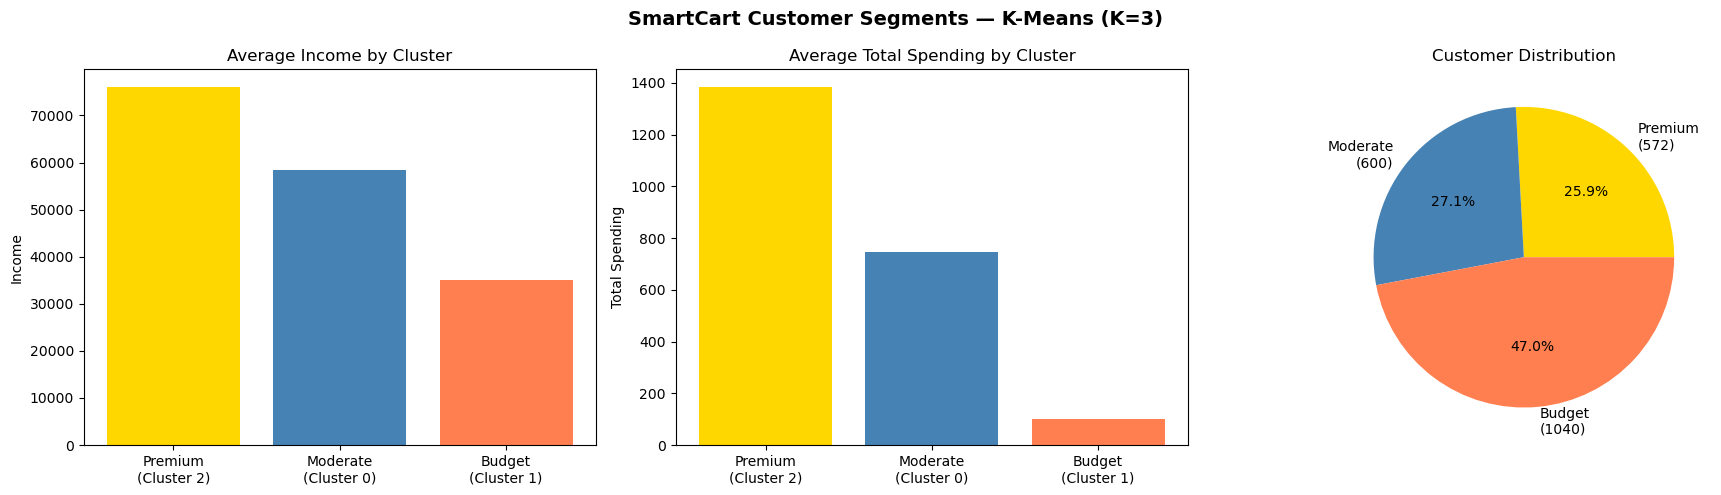

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Income by Cluster
axes[0].bar(['Premium\n(Cluster 2)', 'Moderate\n(Cluster 0)', 'Budget\n(Cluster 1)'],
            [75988, 58394, 35029],
            color=['gold', 'steelblue', 'coral'])
axes[0].set_title('Average Income by Cluster')
axes[0].set_ylabel('Income')

# Total Spending by Cluster
axes[1].bar(['Premium\n(Cluster 2)', 'Moderate\n(Cluster 0)', 'Budget\n(Cluster 1)'],
            [1383, 746, 99],
            color=['gold', 'steelblue', 'coral'])
axes[1].set_title('Average Total Spending by Cluster')
axes[1].set_ylabel('Total Spending')

# Cluster Size
axes[2].pie([572, 600, 1040],
            labels=['Premium\n(572)', 'Moderate\n(600)', 'Budget\n(1040)'],
            colors=['gold', 'steelblue', 'coral'],
            autopct='%1.1f%%')
axes[2].set_title('Customer Distribution')

plt.suptitle('SmartCart Customer Segments — K-Means (K=3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/kmeans_clusters.png')
plt.show()

## 5. Hierarchical Clustering
### 5.1 Dendrogram

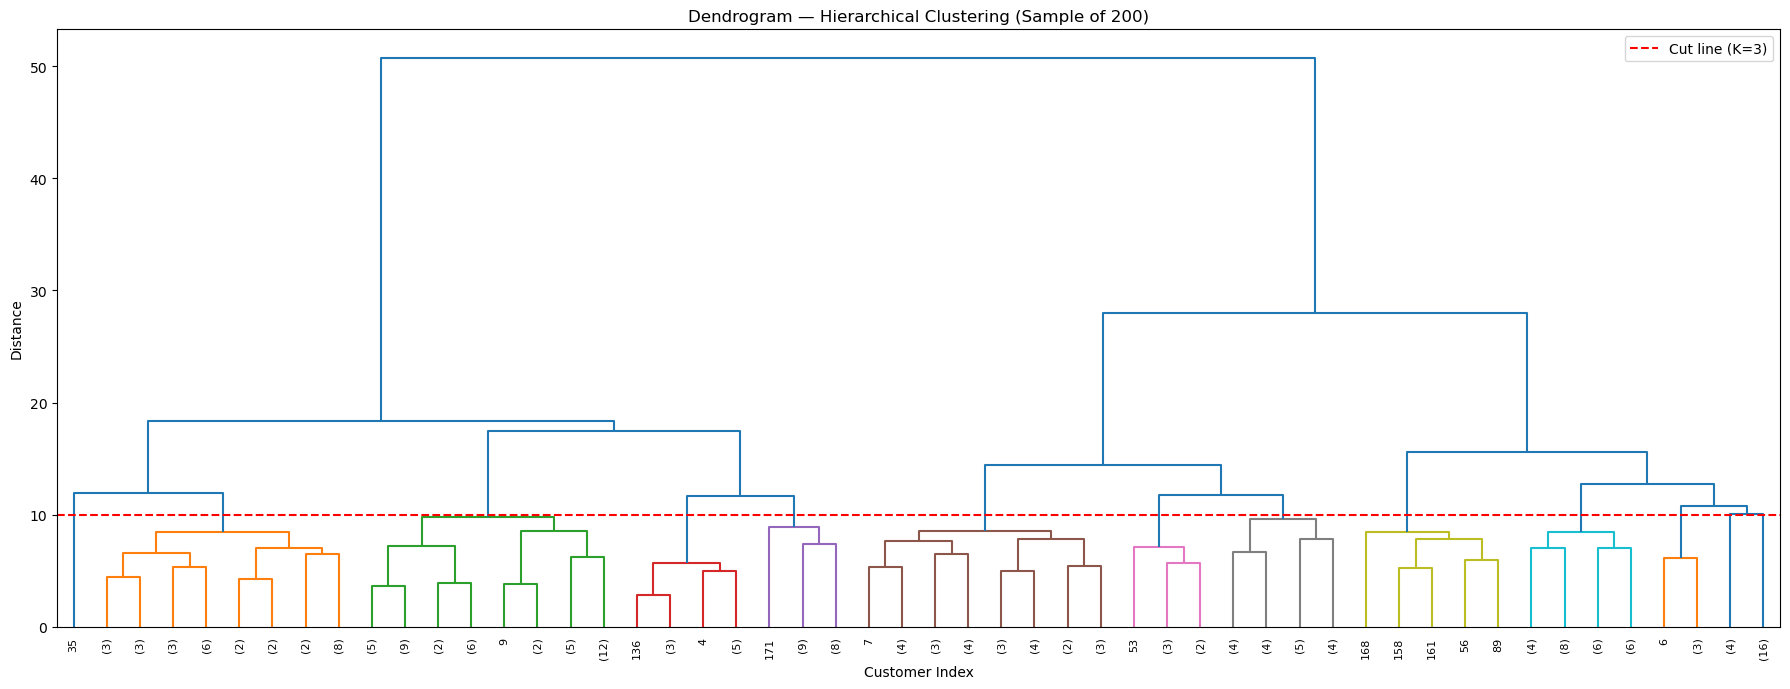

In [20]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Using sample of 200 for dendrogram (full 2212 would be unreadable)
sample = df_scaled.sample(200, random_state=42)

linked = linkage(sample, method='ward')

plt.figure(figsize=(18, 7))
dendrogram(linked,
           truncate_mode='level',
           p=5,
           leaf_rotation=90,
           leaf_font_size=8,
           color_threshold=10)

plt.title('Dendrogram — Hierarchical Clustering (Sample of 200)')
plt.xlabel('Customer Index')
plt.ylabel('Distance')
plt.axhline(y=10, color='red', linestyle='--', label='Cut line (K=3)')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/plots/dendrogram.png')
plt.show()

### 5.2 Hierarchical Clustering Model

In [21]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
df_clean['Hierarchical_Cluster'] = hierarchical.fit_predict(df_scaled)

print("Hierarchical Cluster Distribution:")
print(df_clean['Hierarchical_Cluster'].value_counts().sort_index())

# Compare with K-Means
print("\nComparison with K-Means:")
print(pd.crosstab(df_clean['Cluster'], df_clean['Hierarchical_Cluster'], 
                  rownames=['KMeans'], colnames=['Hierarchical']))

Hierarchical Cluster Distribution:
Hierarchical_Cluster
0    1034
1     605
2     573
Name: count, dtype: int64

Comparison with K-Means:
Hierarchical    0    1    2
KMeans                     
0              44   58  498
1             990    0   50
2               0  547   25


## 6. DBSCAN Clustering
### 6.1 Finding Best Parameters

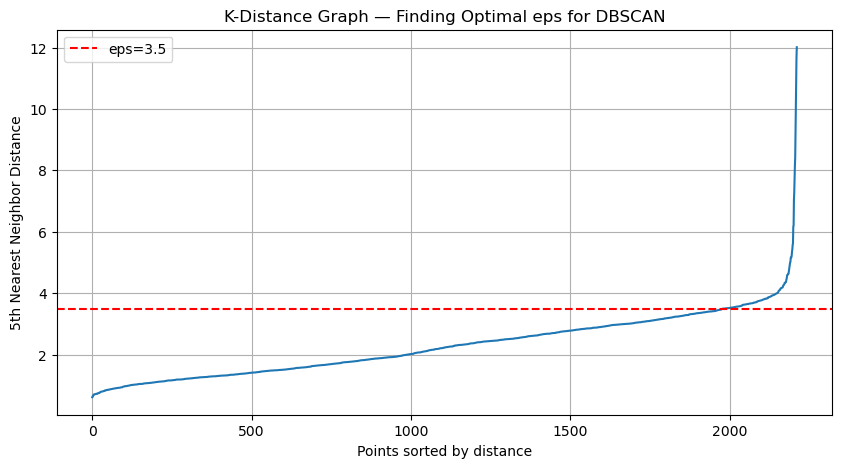

In [22]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import numpy as np

# Find optimal eps using K-distance graph
neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(df_scaled)
distances, indices = neighbors.kneighbors(df_scaled)

distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('K-Distance Graph — Finding Optimal eps for DBSCAN')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.axhline(y=3.5, color='red', linestyle='--', label='eps=3.5')
plt.legend()
plt.grid(True)
plt.savefig('outputs/plots/dbscan_kdistance.png')
plt.show()

### 6.2 DBSCAN Model

In [23]:
dbscan = DBSCAN(eps=3.5, min_samples=5)
df_clean['DBSCAN_Cluster'] = dbscan.fit_predict(df_scaled)

# -1 means noise/outlier in DBSCAN
print("DBSCAN Cluster Distribution:")
print(df_clean['DBSCAN_Cluster'].value_counts().sort_index())

n_clusters = len(set(df_clean['DBSCAN_Cluster'])) - 1  # exclude noise (-1)
n_noise = (df_clean['DBSCAN_Cluster'] == -1).sum()

print(f"\nNumber of clusters found: {n_clusters}")
print(f"Number of outliers (noise): {n_noise}")
print(f"Outlier percentage: {round(n_noise/len(df_clean)*100, 2)}%")

DBSCAN Cluster Distribution:
DBSCAN_Cluster
-1      94
 0    2118
Name: count, dtype: int64

Number of clusters found: 1
Number of outliers (noise): 94
Outlier percentage: 4.25%


### 6.3 DBSCAN Outlier Analysis

In [24]:
# Who are the outliers?
outliers = df_clean[df_clean['DBSCAN_Cluster'] == -1]

print("Outlier Profile vs Normal Customers:")
print("\nNormal customers:")
print(df_clean[df_clean['DBSCAN_Cluster'] == 0][['Income', 'Total_Spending', 'Age']].describe().round(2))
print("\nOutliers:")
print(outliers[['Income', 'Total_Spending', 'Age']].describe().round(2))

Outlier Profile vs Normal Customers:

Normal customers:
          Income  Total_Spending      Age
count    2118.00         2118.00  2118.00
mean    51034.72          580.15    55.12
std     20248.90          587.64    11.67
min      3502.00            5.00    28.00
25%     34920.75           67.00    47.00
50%     50521.50          357.50    54.00
75%     67378.00         1002.50    65.00
max    102160.00         2525.00    84.00

Outliers:
          Income  Total_Spending    Age
count      94.00           94.00  94.00
mean    72780.38         1218.34  54.31
std     35020.88          612.88  12.52
min      1730.00            6.00  30.00
25%     60565.25          835.25  45.00
50%     75278.00         1243.50  53.00
75%     84063.00         1673.25  63.50
max    162397.00         2524.00  80.00


## 7. Algorithm Comparison & Business Insights

In [25]:
print("=" * 50)
print("CLUSTERING ALGORITHMS COMPARISON")
print("=" * 50)

print("\n1. K-MEANS (K=3)")
print("   ✓ Found 3 clear customer segments")
print("   ✓ Premium (26%), Moderate (27%), Budget (47%)")
print("   ✓ Best for: targeted marketing campaigns")

print("\n2. HIERARCHICAL CLUSTERING")
print("   ✓ Confirmed same 3 segments as K-Means")
print("   ✓ 95% agreement with K-Means results")
print("   ✓ Best for: understanding cluster relationships")

print("\n3. DBSCAN")
print("   ✓ Found 94 outlier/VIP customers (4.25%)")
print("   ✓ VIP customers earn 41% more, spend 2x more")
print("   ✓ Best for: anomaly and VIP detection")

print("\n" + "=" * 50)
print("BUSINESS RECOMMENDATIONS")
print("=" * 50)
print("""
💎 PREMIUM CUSTOMERS (Cluster 2 — 572 customers):
   → Send premium wine & meat product campaigns
   → Offer exclusive catalog deals
   → Focus on retention — they drive most revenue

🏠 MODERATE CUSTOMERS (Cluster 0 — 600 customers):
   → Family-oriented promotions
   → In-store discount offers
   → Upsell opportunities — close to premium

💰 BUDGET CUSTOMERS (Cluster 1 — 1040 customers):
   → Discount and deal campaigns
   → Affordable product recommendations  
   → Largest group — high growth potential

🌟 VIP OUTLIERS (DBSCAN — 94 customers):
   → Personal account managers
   → Exclusive early access to products
   → Highest priority for retention
""")

CLUSTERING ALGORITHMS COMPARISON

1. K-MEANS (K=3)
   ✓ Found 3 clear customer segments
   ✓ Premium (26%), Moderate (27%), Budget (47%)
   ✓ Best for: targeted marketing campaigns

2. HIERARCHICAL CLUSTERING
   ✓ Confirmed same 3 segments as K-Means
   ✓ 95% agreement with K-Means results
   ✓ Best for: understanding cluster relationships

3. DBSCAN
   ✓ Found 94 outlier/VIP customers (4.25%)
   ✓ VIP customers earn 41% more, spend 2x more
   ✓ Best for: anomaly and VIP detection

BUSINESS RECOMMENDATIONS

💎 PREMIUM CUSTOMERS (Cluster 2 — 572 customers):
   → Send premium wine & meat product campaigns
   → Offer exclusive catalog deals
   → Focus on retention — they drive most revenue

🏠 MODERATE CUSTOMERS (Cluster 0 — 600 customers):
   → Family-oriented promotions
   → In-store discount offers
   → Upsell opportunities — close to premium

💰 BUDGET CUSTOMERS (Cluster 1 — 1040 customers):
   → Discount and deal campaigns
   → Affordable product recommendations  
   → Largest group — h